# Instalação

Código usado para verificar que tudo está funcionado.

In [1]:
import pandas as pd
import sklearn
import matplotlib

print("TUDO FUNCIONANDO ✅")

TUDO FUNCIONANDO ✅


Esses comandos foram utilizados para preparar o ambiente do projeto e instalar as bibliotecas necessárias para o desenvolvimento do trabalho. O `uv` foi utilizado para criar um ambiente virtual isolado, evitando conflitos com outras bibliotecas do sistema.

Também foram instaladas bibliotecas importantes para o projeto, como:

* `pandas` e `numpy` para manipulação dos dados;
* `matplotlib` para criação de gráficos;
* `scikit-learn` para aplicação das técnicas de machine learning;
* `imbalanced-learn` para suporte a técnicas de balanceamento de dados.

Essa etapa garantiu que todas as ferramentas necessárias estivessem configuradas corretamente antes do início das análises.


In [2]:
# Instala o uv (caso não esteja instalado no ambiente base)
%pip install uv

# Cria o ambiente virtual (.venv) no diretório atual e força a substituição se já existir
!uv venv --clear 
# Voce pode desabilitar essa linha se ja tiver o .venv no projeto.

# Instala as bibliotecas necessárias
!uv pip install pandas numpy matplotlib scikit-learn imbalanced-learn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
Using CPython 3.12.10 interpreter at: C:\Users\maick\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe
Creating virtual environment at: .venv
Activate with: .venv\Scripts\activate
Using Python 3.13.0 environment at: c:\Users\maick\OneDrive\Área de Trabalho\Faculdade\Visão computacional\.venv
Checked 5 packages in 341ms


O comando `!uv pip install ipykernel` foi utilizado para instalar o pacote `ipykernel` no ambiente virtual do projeto. Esse pacote permite integrar o ambiente Python ao Jupyter Notebook, possibilitando a execução dos códigos diretamente no notebook utilizando o ambiente configurado para o projeto.

A utilização do `ipykernel` garante que todas as bibliotecas instaladas no ambiente virtual estejam disponíveis durante o desenvolvimento do trabalho, evitando conflitos de versões e problemas de compatibilidade entre dependências.

In [3]:
!uv pip install ipykernel

Using Python 3.13.0 environment at: c:\Users\maick\OneDrive\Área de Trabalho\Faculdade\Visão computacional\.venv
Checked 1 package in 367ms


Esse comando foi utilizado para registrar o ambiente virtual do projeto como um kernel no Jupyter Notebook. Com isso, o notebook passa a utilizar exatamente as bibliotecas instaladas no ambiente criado para o trabalho, garantindo mais organização e evitando problemas de compatibilidade durante a execução dos códigos.

In [8]:
!uv run python -m ipykernel install --user --name medical_cost_personal_datasets --display-name "medical-cost-personal-datasets (uv)"

Installed kernelspec medical_cost_personal_datasets in C:\Users\maick\AppData\Roaming\jupyter\kernels\medical_cost_personal_datasets


Esse bloco foi utilizado para importar as bibliotecas necessárias para o desenvolvimento do projeto. As bibliotecas `pandas` e `numpy` foram usadas para manipulação dos dados, enquanto o `matplotlib` auxiliou na criação de gráficos para análise visual.

Também foram importadas ferramentas do `scikit-learn` para etapas importantes do machine learning, como normalização dos dados, separação entre treino e teste, seleção de variáveis, treinamento do modelo Random Forest e avaliação dos resultados obtidos.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# from imblearn.over_sampling import SMOTE

# Carregar Dataset

Esse código foi utilizado para carregar o dataset `insurance.csv` no projeto utilizando a biblioteca `pandas`. Em seguida, a função `head()` foi usada para visualizar as primeiras linhas da tabela, permitindo uma análise inicial da estrutura e das informações presentes no conjunto de dados.

In [11]:
df = pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


# Análise Exploratória (EAD)

A função info() foi utilizada para obter uma visão geral do dataset, permitindo identificar a quantidade de registros, os tipos de variáveis e a presença de valores nulos

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


Dicionário de dados (features)
- Colocar todas as colunas/categorias do csv

A função describe() foi utilizada para analisar estatisticamente as variáveis numéricas do dataset.

In [13]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


Usado para verificar verificar valores nulos explicitamente.

In [19]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Esse código foi utilizado para verificar a quantidade de registros duplicados presentes no dataset.

In [16]:
df.duplicated().sum()

np.int64(1)

# Visualização

Esse código foi utilizado para gerar histogramas das variáveis numéricas do dataset. Os gráficos ajudam a visualizar a distribuição dos dados, facilitando a identificação de padrões, concentrações de valores e possíveis outliers presentes nas informações.

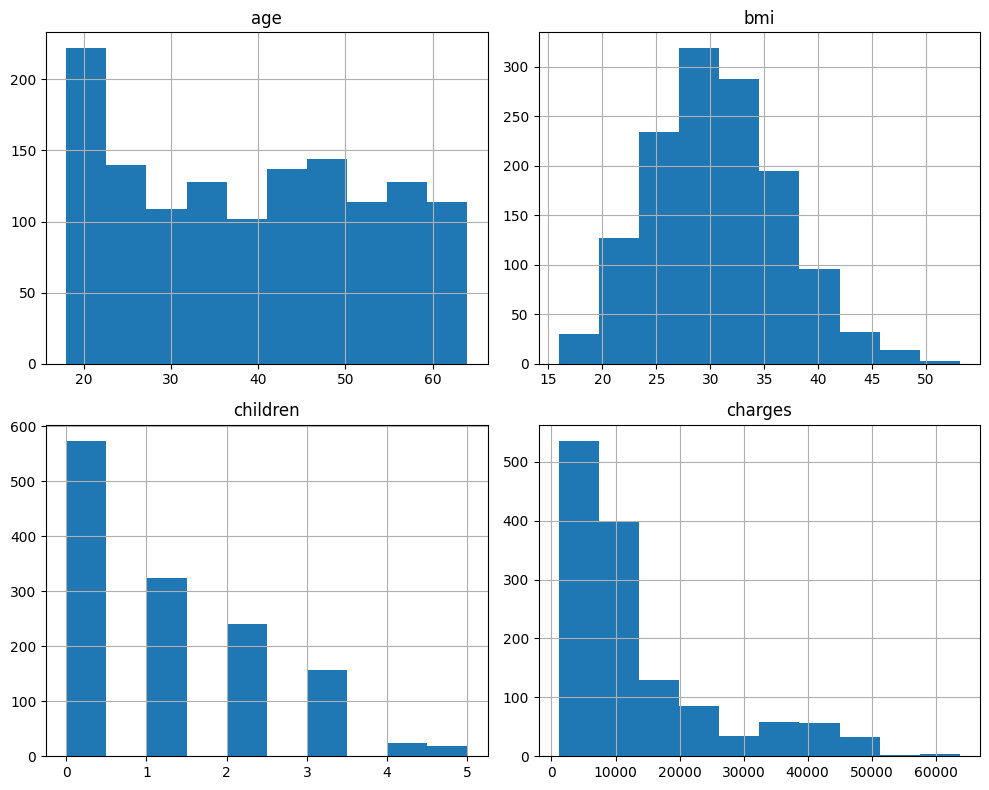

In [15]:
df.hist(figsize=(10, 8))
plt.tight_layout()
plt.show()

# Limpeza de Dados

Esse código foi utilizado para remover registros duplicados do dataset, ajudando a manter os dados mais organizados e consistentes. Em seguida, a função `info()` foi utilizada para visualizar informações gerais do conjunto de dados, como quantidade de registros, tipos das colunas e presença de valores nulos.

In [17]:
df = df.drop_duplicates() # Elimina linhas duplicadas
df.info()

<class 'pandas.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1337 non-null   int64  
 1   sex       1337 non-null   str    
 2   bmi       1337 non-null   float64
 3   children  1337 non-null   int64  
 4   smoker    1337 non-null   str    
 5   region    1337 non-null   str    
 6   charges   1337 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 83.6 KB


Esse comando foi utilizado para verificar as dimensões do dataset, mostrando a quantidade de linhas e colunas presentes após as etapas de limpeza dos dados.

In [18]:
df.shape

(1337, 7)

# Tratamento de Outliers

Esse código foi utilizado para criar um boxplot da variável `charges`. O gráfico ajuda a visualizar a distribuição dos custos médicos e identificar possíveis outliers, ou seja, valores muito diferentes da maioria dos dados.

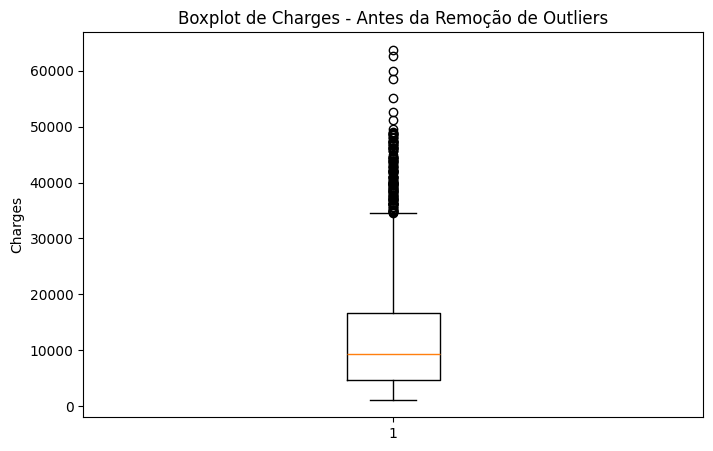

In [20]:
plt.figure(figsize=(8,5))
plt.boxplot(df['charges'])
plt.title("Boxplot de Charges - Antes da Remoção de Outliers")
plt.ylabel("Charges")
plt.show()


Esse código foi utilizado para calcular os quartis e o intervalo interquartil (IQR) da variável `charges`. A partir desses valores, foram definidos os limites inferior e superior usados para identificar possíveis outliers no dataset.

In [21]:
Q1 = df['charges'].quantile(0.25)
Q3 = df['charges'].quantile(0.75)

IQR = Q3 - Q1

# Limites inferior e superior
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"Q1: {Q1}")
print(f"Q3: {Q3}")
print(f"IQR: {IQR}")
print(f"Limite inferior: {lower}")
print(f"Limite superior: {upper}")

Q1: 4746.344
Q3: 16657.71745
IQR: 11911.37345
Limite inferior: -13120.716174999998
Limite superior: 34524.777625


Esse código foi utilizado para identificar os valores considerados outliers na variável `charges`, com base nos limites calculados anteriormente pelo método IQR. Em seguida, foi exibida a quantidade de registros classificados como valores extremos no dataset.

In [22]:
outliers = df[
    (df['charges'] < lower) |
    (df['charges'] > upper)
]

print(f"\nQuantidade de outliers encontrados: {outliers.shape[0]}")


Quantidade de outliers encontrados: 139


Esse código foi utilizado para criar uma nova versão do dataset sem os valores considerados outliers na variável `charges`. Em seguida, foi feita uma comparação entre o tamanho do dataset original e o dataset após a remoção dos valores extremos.

In [23]:
df_sem_outliers = df[
    (df['charges'] >= lower) &
    (df['charges'] <= upper)
]

print("\nShape antes da remoção:", df.shape)
print("Shape depois da remoção:", df_sem_outliers.shape)


Shape antes da remoção: (1337, 7)
Shape depois da remoção: (1198, 7)


Esse código foi utilizado para gerar um novo boxplot da variável `charges` após a remoção dos outliers. O gráfico permite visualizar como os dados ficaram distribuídos depois do processo de limpeza dos valores extremos.

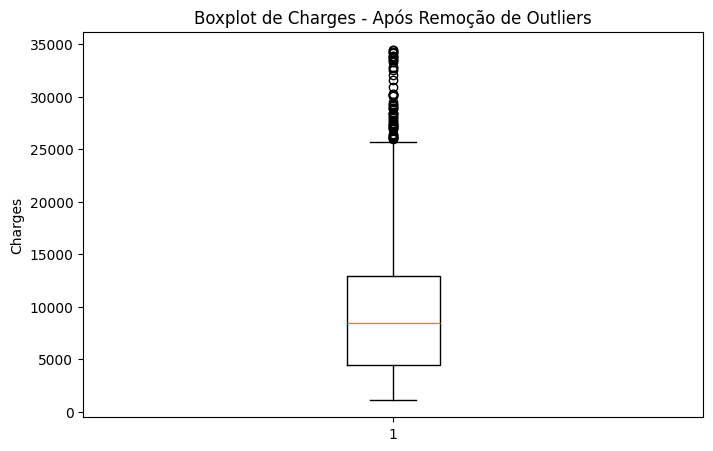

In [24]:
plt.figure(figsize=(8,5))
plt.boxplot(df_sem_outliers['charges'])
plt.title("Boxplot de Charges - Após Remoção de Outliers")
plt.ylabel("Charges")
plt.show()

# Transformações Estatísticas

Esse código foi utilizado para criar um gráfico de linha da variável `charges`. O objetivo foi visualizar a variação dos custos médicos ao longo dos registros do dataset e identificar possíveis picos ou valores muito elevados.

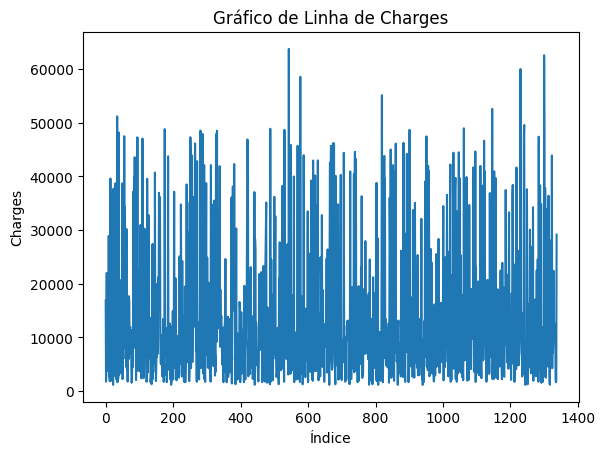

In [25]:
plt.plot(df['charges'])
plt.title("Gráfico de Linha de Charges")
plt.xlabel("Índice")
plt.ylabel("Charges")
plt.show()

Esse código foi utilizado para aplicar uma transformação logarítmica na variável `charges`, criando uma nova coluna chamada `charges_log`. Essa transformação ajuda a reduzir a assimetria dos dados e diminuir o impacto de valores muito altos, facilitando a análise e o treinamento do modelo.

In [27]:
df['charges_log'] = np.log1p(df['charges'])
print(df['charges_log'])

0        9.734236
1        7.453882
2        8.400763
3        9.998137
4        8.260455
          ...    
1333     9.268755
1334     7.699381
1335     7.396847
1336     7.605365
1337    10.279948
Name: charges_log, Length: 1337, dtype: float64


Esse código foi utilizado para criar um gráfico de linha da variável `charges_log` após a transformação logarítmica. O gráfico ajuda a visualizar como os valores ficaram mais distribuídos e com menor influência de valores extremos.

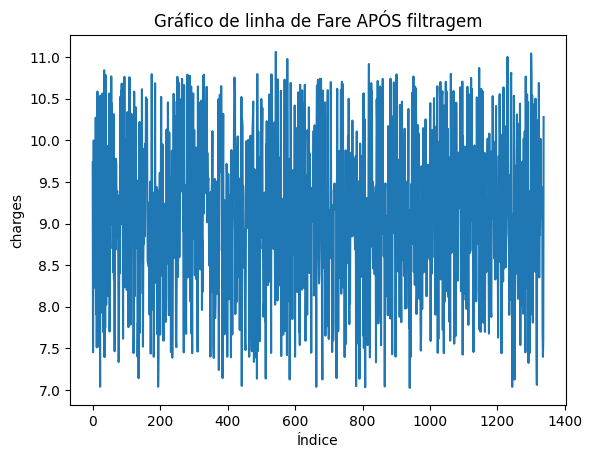

In [28]:
plt.plot(df['charges_log'])
plt.title("Gráfico de linha de Fare APÓS filtragem")
plt.xlabel("Índice")
plt.ylabel("charges")
plt.show()

Esse código foi utilizado para padronizar as variáveis numéricas do dataset utilizando o `StandardScaler`. Esse processo coloca os dados em uma escala semelhante, facilitando o processamento e a análise pelo modelo de machine learning.

In [29]:
scaler = StandardScaler()

df[['age', 'bmi', 'children', 'charges_log']] = scaler.fit_transform(
    df[['age', 'bmi', 'children', 'charges_log']]
)

Esse código foi utilizado para visualizar, por meio de gráficos de linha, como as variáveis `age` e `charges_log` ficaram após o processo de normalização. A visualização ajuda a observar o comportamento dos dados padronizados e comparar a distribuição das variáveis.

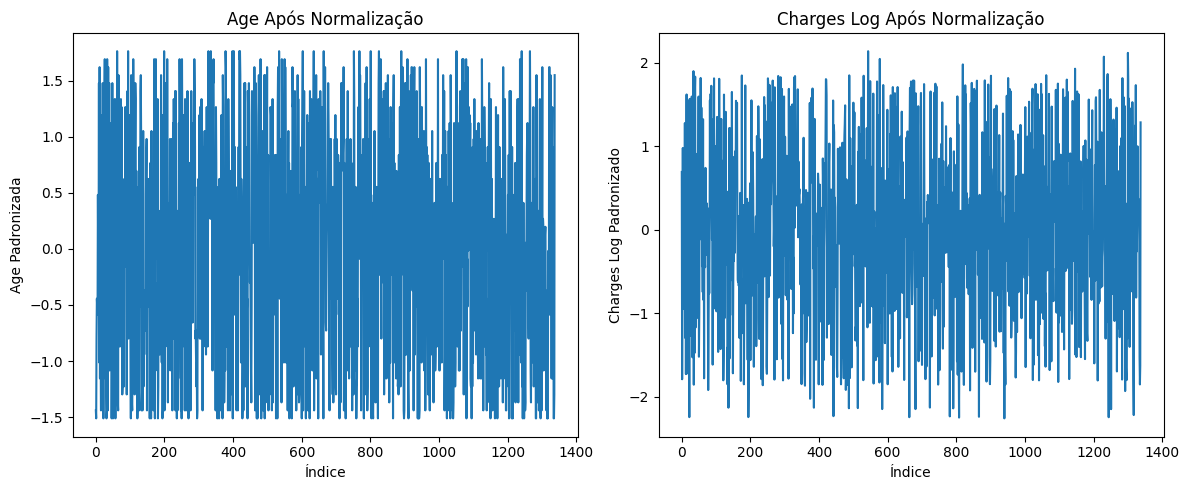

In [ ]:
plt.figure(figsize=(12, 5))



plt.subplot(1, 2, 1)
plt.plot(df['age'])

plt.title("Age Após Normalização")
plt.xlabel("Índice")
plt.ylabel("Age Padronizada")


plt.subplot(1, 2, 2)
plt.plot(df['charges_log'])

plt.title("Charges Log Após Normalização")
plt.xlabel("Índice")
plt.ylabel("Charges Log Padronizado")

plt.tight_layout()
plt.show()

Esse código foi utilizado para aplicar o One-Hot Encoding nas variáveis categóricas `sex`, `smoker` e `region`. Esse processo transforma valores textuais em valores numéricos, permitindo que o modelo de machine learning consiga interpretar corretamente essas informações.

In [31]:
df = pd.get_dummies(
    df,
    columns=['sex', 'smoker', 'region'],
    drop_first=True
)

Esse código foi utilizado para visualizar algumas das novas colunas criadas após o processo de One-Hot Encoding. A exibição das primeiras linhas ajuda a confirmar que as variáveis categóricas foram convertidas corretamente em valores numéricos.

In [32]:
print("Colunas após One-Hot Encoding:")

display(
    df[
        [
            'sex_male',
            'smoker_yes',
            'region_northwest',
            'region_southeast',
            'region_southwest'
        ]
    ].head()
)

Colunas após One-Hot Encoding:


,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,False,True,False,False,True
1,True,False,False,True,False
2,True,False,False,True,False
3,True,False,True,False,False
4,True,False,True,False,False


Esse comando foi utilizado para visualizar informações gerais do dataset, como quantidade de registros, tipos das colunas e presença de valores nulos. Após as transformações realizadas, ele também ajudou a verificar se as variáveis categóricas foram convertidas corretamente em valores numéricos.

In [33]:
df.info()

<class 'pandas.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               1337 non-null   float64
 1   bmi               1337 non-null   float64
 2   children          1337 non-null   float64
 3   charges           1337 non-null   float64
 4   charges_log       1337 non-null   float64
 5   sex_male          1337 non-null   bool   
 6   smoker_yes        1337 non-null   bool   
 7   region_northwest  1337 non-null   bool   
 8   region_southeast  1337 non-null   bool   
 9   region_southwest  1337 non-null   bool   
dtypes: bool(5), float64(5)
memory usage: 69.2 KB


# Seleção de Features

Esse código foi utilizado para separar as variáveis do dataset entre entradas (`X`) e variável alvo (`y`). As variáveis em `X` serão usadas pelo modelo para realizar as previsões, enquanto `charges` foi definida como a variável que o modelo deverá prever.

In [34]:
X = df.drop(columns=['charges'])
y = df['charges']

# Split do Dataset

Esse código foi utilizado para dividir o dataset em conjuntos de treino e teste. O conjunto de treino foi usado para ensinar o modelo, enquanto o conjunto de teste foi reservado para avaliar o desempenho das previsões realizadas.

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)